# Forecasting NOK/USD from the oil-futures term structure

This notebook is a **readable narrative** on top of the modular code in `src/`.
Each analysis step calls a `src` module (which can also be run standalone from
the terminal) and explains what and why along the way.

**Data source:** local Datastream/Refinitiv extracts — the real ICE Brent term
structure `TRc1`–`TRc12` (full 1–12 month curve) and NOK/USD, monthly 2001–2021.

**Goal:** test whether the *shape* of the term structure (compressed into the
Diebold–Li factors level/slope/curvature) can forecast the krone better than a
naive random walk — under two out-of-sample windowing schemes (expanding and
rolling).

In [1]:
import sys
from pathlib import Path

# Make src/ importable whether the notebook runs from the root or notebooks/
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, display
from src import config

def show(*names):
    for n in names:
        display(Image(filename=str(config.OUTPUT_DIR / n)))

def show_csv(name, index_col=0):
    return pd.read_csv(config.OUTPUT_DIR / name, index_col=index_col)

## Step 1 — Data acquisition and alignment

We read NOK/USD and the Brent term structure through the modular `data_loader`
interface and align them on a common monthly date index. `M1` (front-month) is
the "first nearby". The result is 243 complete months with no gaps.

In [2]:
from src.data_acquisition import build_dataset
df = build_dataset()
df.head()

[data] Term-structure source: Excel: ICE Brent TRc1-TRc12 (real, full 1-12 curve, monthly)
[data] FX: NOKUSD  (2001-01-31 -> 2021-03-31)
[data] Maturities: ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'M10', 'M11', 'M12']
[data] 243 months before align -> 243 complete months (2001-01-31 -> 2021-03-31)
[data] Saved to C:\Users\jonas\Desktop\CCfolder\currency_forecasting\data\dataset.parquet


,NOKUSD,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12
date,,,,,,,,,,,,,
2001-01-31,0.114055,26.66,25.71,25.46,25.22,25.00,24.77,24.53,24.30,24.09,23.89,23.60,23.35
2001-02-28,0.112199,25.57,25.71,25.71,25.53,25.31,25.11,24.91,24.71,24.49,24.15,23.91,23.61
2001-03-31,0.109105,24.74,24.92,24.85,24.74,24.60,24.45,24.30,24.13,23.89,23.69,23.49,23.25
2001-04-30,0.110216,27.89,27.66,27.28,27.01,26.73,26.44,26.13,25.82,25.52,25.22,24.92,24.62
2001-05-31,0.106720,29.34,28.00,27.53,27.23,26.93,26.60,26.24,25.92,25.59,25.26,24.95,24.69


## Step 2 — Exploratory analysis

Three questions before modelling: (1) Do the krone and oil move together?
(2) Is the relationship stable? (3) What does the term structure look like?

We compute correlation on **monthly changes** (not levels), since two trending
level series easily give an artificially high correlation.

[eda] 243 monthly observations (2001-01-31 -> 2021-03-31)
[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\02_nokusd_vs_frontmonth.png
[eda] Correlation (returns) NOK/USD vs Brent M1: 0.532


[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\02_rolling_corr_60m.png
[eda] Rolling corr: mean 0.54, min 0.06, max 0.72
[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\02_term_structure_3d.png


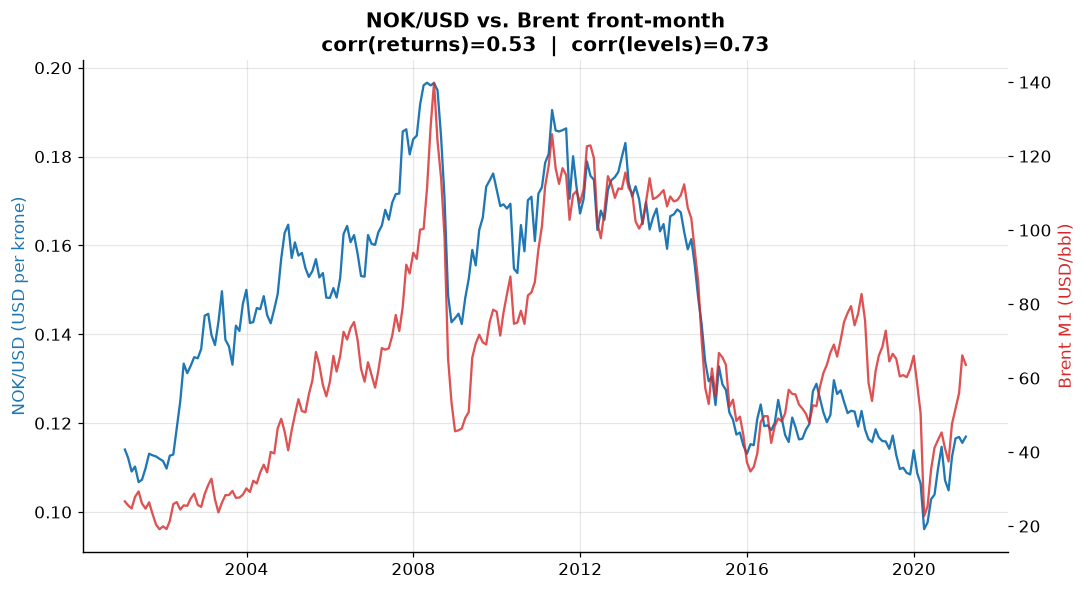

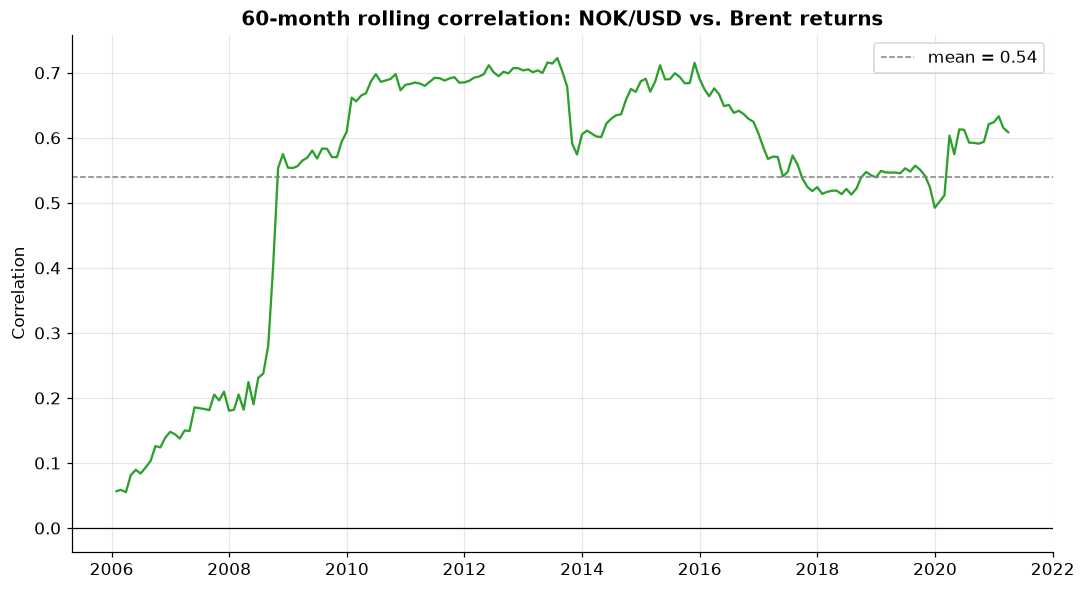

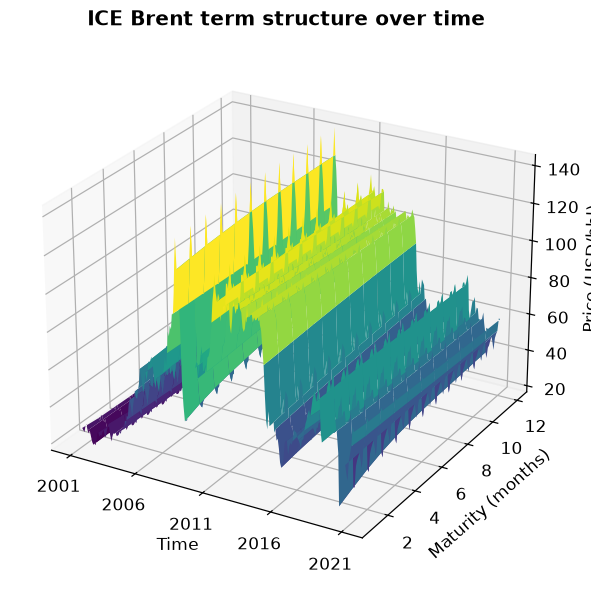

In [3]:
from src import eda
eda.run()
show("02_nokusd_vs_frontmonth.png", "02_rolling_corr_60m.png", "02_term_structure_3d.png")

## Step 3 — Diebold-Li factors

We compress the whole curve into three interpretable numbers per month:

$$ y(\tau) = \beta_1 + \beta_2\frac{1-e^{-\lambda\tau}}{\lambda\tau} + \beta_3\left(\frac{1-e^{-\lambda\tau}}{\lambda\tau}-e^{-\lambda\tau}\right) $$

* **Level** ($\beta_1$): the whole curve up/down (≈ the oil price level).
* **Slope** ($\beta_2$): short vs. long end (contango/backwardation).
* **Curvature** ($\beta_3$): a mid-curve hump.

$\lambda$ is chosen by a grid search that minimises the fit error; the curvature
loading then peaks in the middle of our 1–12 month window.

[dl] Chosen lambda = 0.23  ->  curvature peak ~ 7.8 months
[dl] Average fit RMSE: 0.085 USD/bbl (mean price ~66)


[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\03_factor_loadings.png


[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\03_dl_factors.png
[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\03_sample_fit.png
[dl] Saved factors to C:\Users\jonas\Desktop\CCfolder\currency_forecasting\data\factors.parquet
[dl] corr(Level, M1) = 0.950


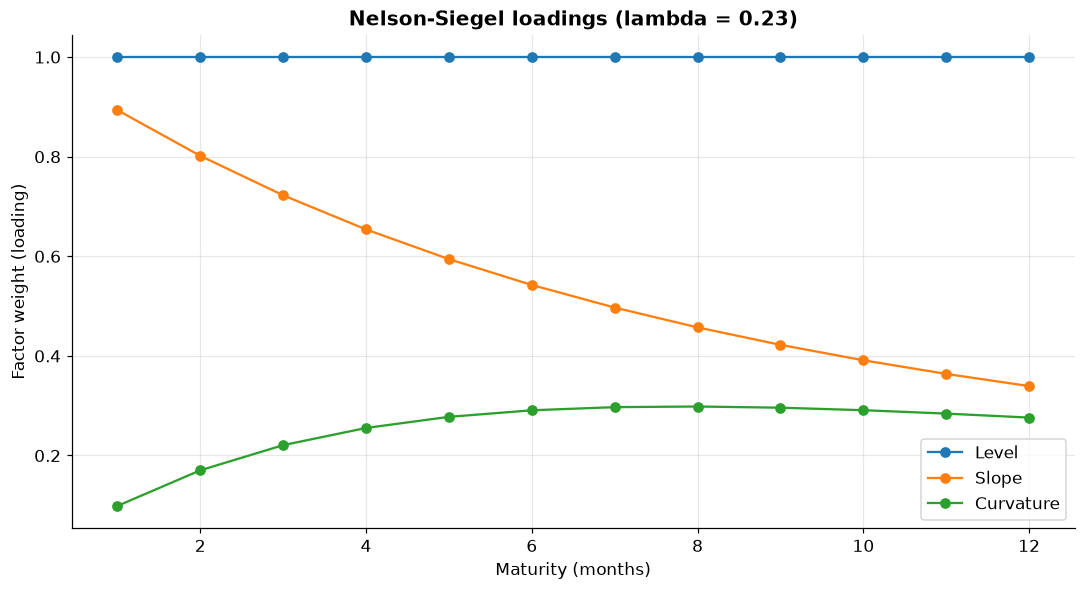

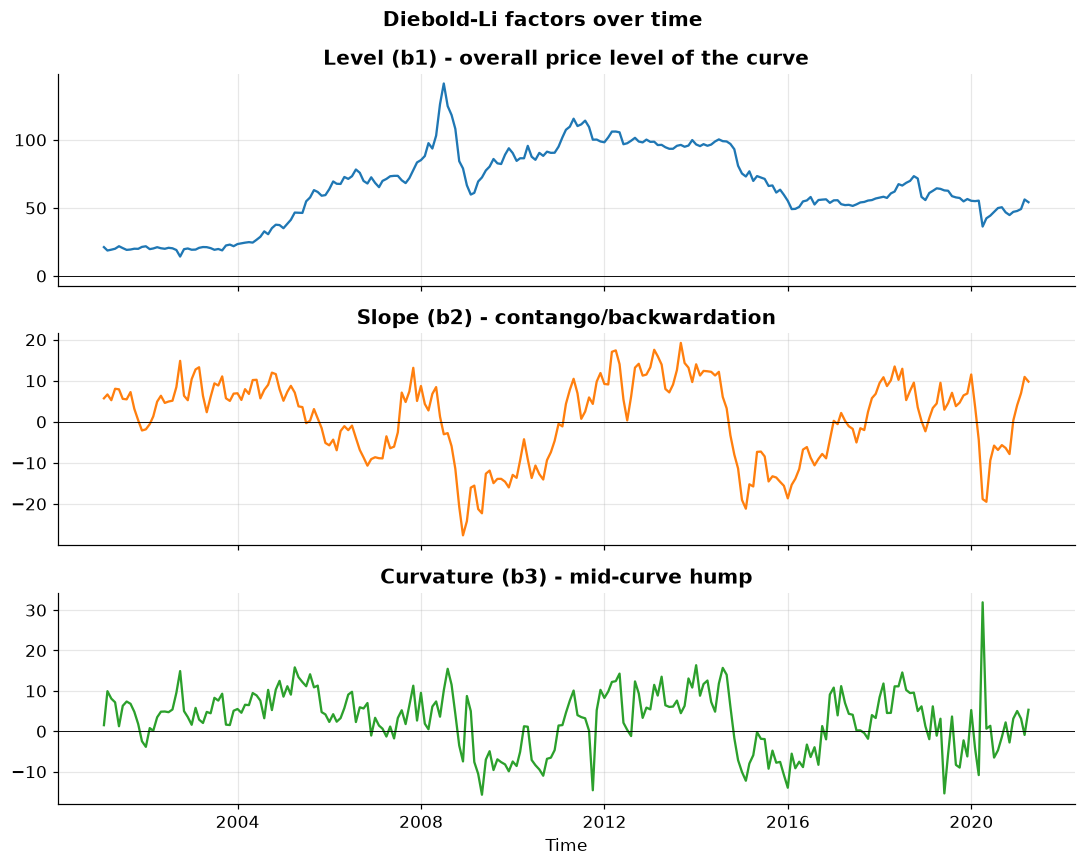

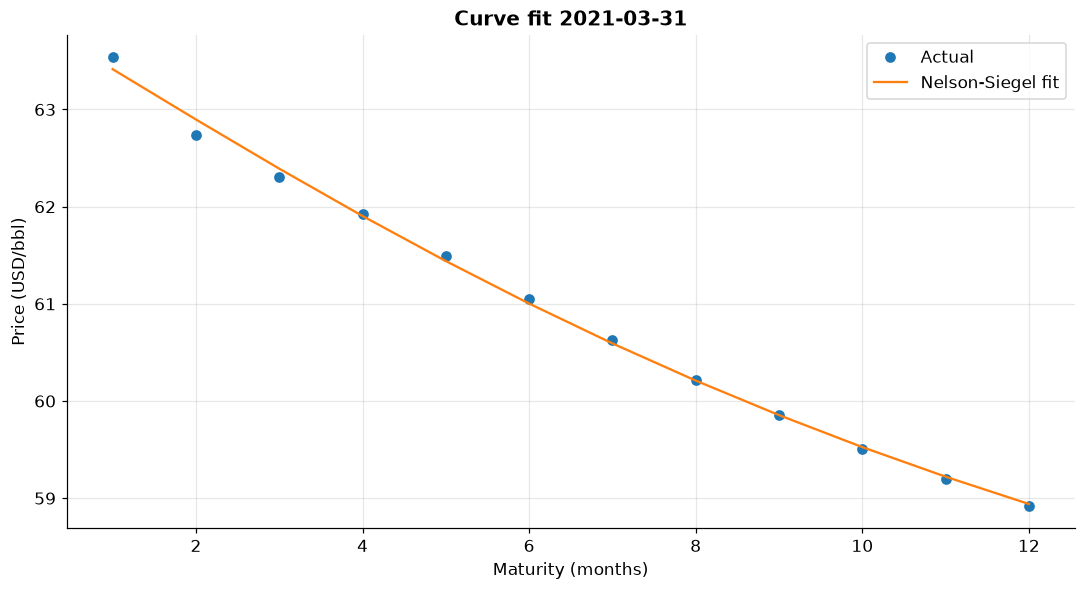

,Level,Slope,Curvature
date,,,
2001-01-31,21.154169,5.707558,1.509750
2001-02-28,18.663796,6.653857,9.921115
2001-03-31,19.274442,5.252150,8.076571
2001-04-30,19.972224,8.036444,7.167707
2001-05-31,21.810950,7.899744,1.241018


In [4]:
from src import diebold_li
factors = diebold_li.run()
show("03_factor_loadings.png", "03_dl_factors.png", "03_sample_fit.png")
factors.head()

## Step 4 — Rolling out-of-sample forecasts

We forecast NOK/USD one month ahead by modelling the **change** $\Delta y_{t+1}$
from information known at time $t$, and set the level forecast = $y_t + \widehat{\Delta y}$.

At each step the model is trained only on the past — no leakage. Models: simple/
multiple regression, AR(1), Elastic Net, a PyTorch LSTM, and an inverse-MSE
combination. Benchmarks: random walk with and without drift.

This is run under **two windowing schemes**:
* **expanding** (recursive): train on all past data;
* **rolling** (fixed 60 months): train on the most recent 60 months only.

*(The LSTM is retrained at every step; this cell takes ~1 minute for both schemes.)*

In [5]:
from src import forecasting
preds = forecasting.run()   # dict: {"expanding": df, "rolling": df}
preds["rolling"][["y_true", "Multiple", "Combination", "LSTM", "RW"]].head()

[fc:expanding] 2006-03-31  (OOS #1)


[fc:expanding] 2009-03-31  (OOS #37)


[fc:expanding] 2012-03-31  (OOS #73)


[fc:expanding] 2015-03-31  (OOS #109)


[fc:expanding] 2018-03-31  (OOS #145)


...

[fc:rolling] 2012-03-31  (OOS #73)


[fc:rolling] 2015-03-31  (OOS #109)


[fc:rolling] 2018-03-31  (OOS #145)


[fc:rolling] 2021-03-31  (OOS #181)
[fc:rolling] 181 OOS forecasts saved to C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\forecasts_rolling.parquet


,y_true,Multiple,Combination,LSTM,RW
date,,,,,
2006-03-31,0.152613,0.147542,0.148517,0.149234,0.148260
2006-04-30,0.162562,0.152458,0.153074,0.153155,0.152613
2006-05-31,0.164382,0.163733,0.165340,0.172358,0.162562
2006-06-30,0.160730,0.165144,0.166395,0.170639,0.164382
2006-07-31,0.162324,0.161010,0.160979,0.159130,0.160730


## Step 5 — Evaluation

RMSE vs. the random walk, CSSED over time, and the Diebold-Mariano test to decide
whether the differences are statistically significant — for **both** schemes, plus
a direct comparison.

In [6]:
from src import evaluation
evaluation.run()

[eval:expanding] 181 OOS forecasts (2006-03-31 -> 2021-03-31)
[eval:expanding] RMSE table:
       model     RMSE  RMSE_rel_RW
Combination 0.005224     0.999572
         RW 0.005226     1.000000
   Multiple 0.005255     1.005615
   RW_drift 0.005260     1.006474
 ElasticNet 0.005279     1.010154
         AR 0.005306     1.015236
     Linear 0.005315     1.017092
       LSTM 0.006318     1.208866


[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\05_pred_vs_true_expanding.png


[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\05_cssed_expanding.png
[eval:expanding] DM vs RW (negative stat = better than RW):
       model  DM_stat_vs_RW  p_value_vs_RW
     Linear         2.1395         0.0337
   Multiple         0.2540         0.7998
         AR         1.2977         0.1961
 ElasticNet         1.0739         0.2843
       LSTM         3.0289         0.0028
Combination        -0.0262         0.9791
[eval:rolling] 181 OOS forecasts (2006-03-31 -> 2021-03-31)
[eval:rolling] RMSE table:
       model     RMSE  RMSE_rel_RW
   Multiple 0.005158     0.986969
Combination 0.005195     0.994103
         RW 0.005226     1.000000
   RW_drift 0.005251     1.004860
 ElasticNet 0.005276     1.009531
     Linear 0.005329     1.019632
         AR 0.005392     1.031744
       LSTM 0.006460     1.236024


[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\05_pred_vs_true_rolling.png


[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\05_cssed_rolling.png
[eval:rolling] DM vs RW (negative stat = better than RW):
       model  DM_stat_vs_RW  p_value_vs_RW
     Linear         1.8998         0.0591
   Multiple        -0.4751         0.6353
         AR         1.8458         0.0666
 ElasticNet         0.5614         0.5752
       LSTM         2.9945         0.0031
Combination        -0.3258         0.7450
[eval] RMSE comparison (expanding vs rolling):
              expanding   rolling
model                           
Linear        0.005315  0.005329
Multiple      0.005255  0.005158
AR            0.005306  0.005392
ElasticNet    0.005279  0.005276
LSTM          0.006318  0.006460
Combination   0.005224  0.005195
RW            0.005226  0.005226
RW_drift      0.005260  0.005251


[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\05_rmse_compare.png


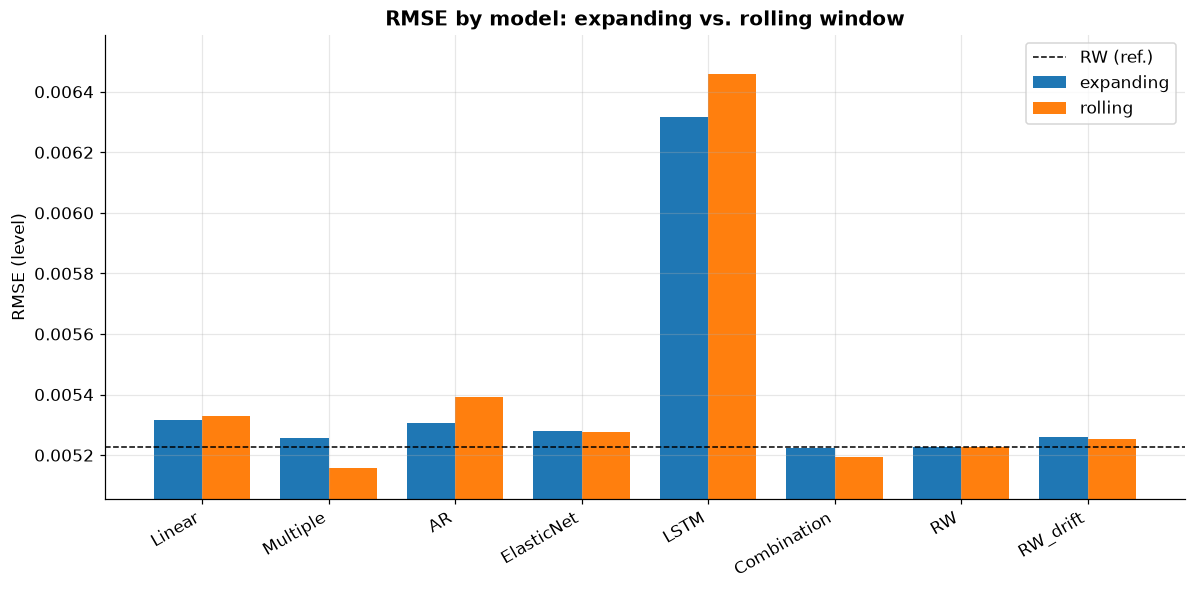

,expanding,rolling
model,,
Linear,0.005315,0.005329
Multiple,0.005255,0.005158
AR,0.005306,0.005392
ElasticNet,0.005279,0.005276
LSTM,0.006318,0.006460
Combination,0.005224,0.005195
RW,0.005226,0.005226
RW_drift,0.005260,0.005251


In [7]:
# Side-by-side RMSE: expanding vs rolling
show("05_rmse_compare.png")
show_csv("05_rmse_compare.csv").round(6)

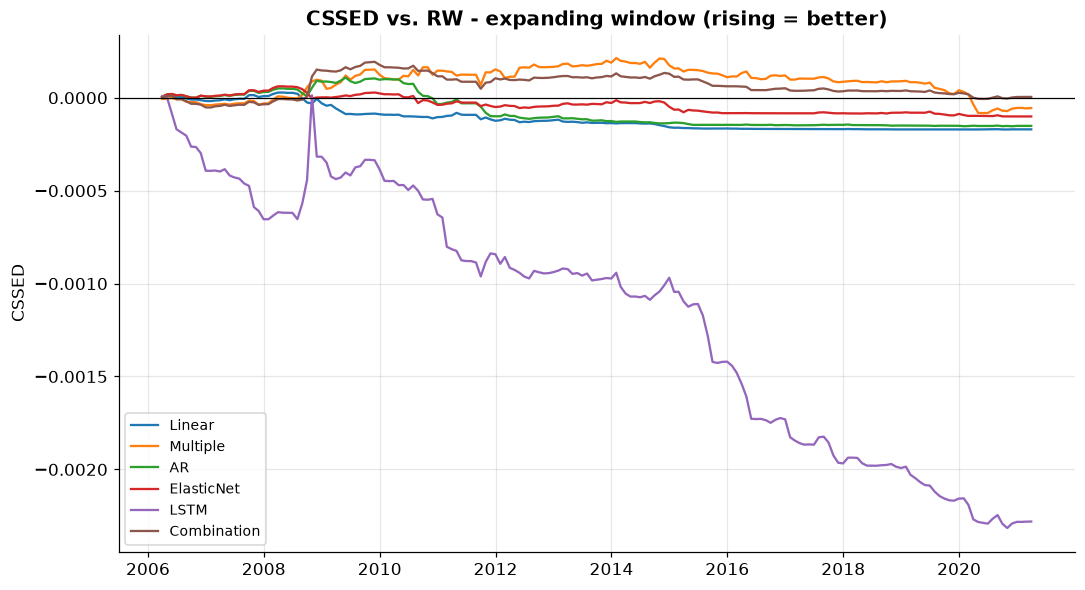

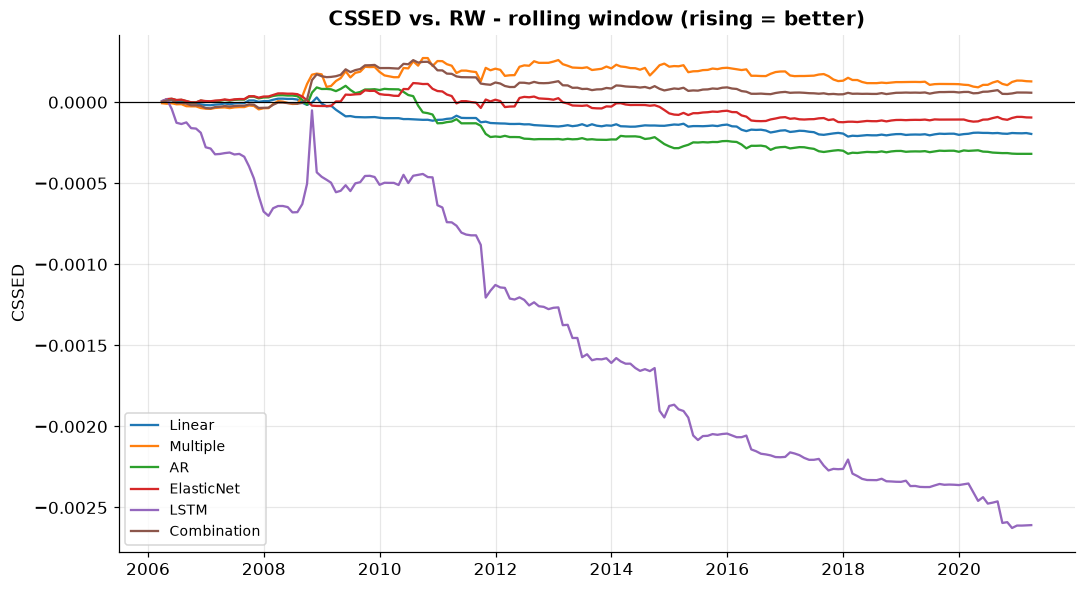

In [8]:
# CSSED vs random walk under both schemes
show("05_cssed_expanding.png", "05_cssed_rolling.png")

In [9]:
# Diebold-Mariano vs RW (negative stat = better than RW)
print("Expanding:")
display(show_csv("05_dm_vs_rw_expanding.csv", index_col=None).round(4))
print("Rolling:")
display(show_csv("05_dm_vs_rw_rolling.csv", index_col=None).round(4))

Expanding:


,model,DM_stat_vs_RW,p_value_vs_RW
0,Linear,2.1395,0.0337
1,Multiple,0.2540,0.7998
2,AR,1.2977,0.1961
3,ElasticNet,1.0739,0.2843
4,LSTM,3.0289,0.0028
5,Combination,-0.0262,0.9791


Rolling:


,model,DM_stat_vs_RW,p_value_vs_RW
0,Linear,1.8998,0.0591
1,Multiple,-0.4751,0.6353
2,AR,1.8458,0.0666
3,ElasticNet,0.5614,0.5752
4,LSTM,2.9945,0.0031
5,Combination,-0.3258,0.7450


**Finding:** No model beats the random walk *significantly* (DM). Under the
**rolling** window, `Multiple` and `Combination` edge just below RW on RMSE, while
the LSTM is significantly worse under both schemes. This is in line with
Meese–Rogoff: currencies are very hard to beat with a random walk.

## Step 6 — Profitability

A simple sign strategy: long/short the krone on the predicted direction. The
point — low RMSE and a profitable *direction* are not the same. The adaptive
(rolling) window improves almost everything.

[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\06_cumulative_returns_expanding.png
[trade:expanding] Strategy stats:
              total_return  ann_return  ann_vol  sharpe  hit_rate
Multiple            1.051       0.055    0.119   0.459     0.541
Combination         0.286       0.024    0.120   0.198     0.519
LSTM               -0.004       0.007    0.120   0.057     0.503
ElasticNet         -0.071       0.002    0.120   0.020     0.525
BuyHold            -0.211      -0.008    0.120  -0.071       NaN
AR                 -0.340      -0.020    0.120  -0.170     0.503
Linear             -0.628      -0.058    0.119  -0.490     0.492


[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\06_cumulative_returns_rolling.png
[trade:rolling] Strategy stats:
              total_return  ann_return  ann_vol  sharpe  hit_rate
Multiple            1.187       0.059    0.119   0.496     0.569
Combination         0.691       0.042    0.120   0.351     0.558
LSTM                0.274       0.023    0.120   0.193     0.530
ElasticNet          0.063       0.011    0.120   0.094     0.519
BuyHold            -0.211      -0.008    0.120  -0.071       NaN
Linear             -0.313      -0.018    0.120  -0.148     0.503
AR                 -0.389      -0.025    0.120  -0.212     0.514
[trade] Strategy comparison (expanding vs rolling):
                expanding                      rolling                
            total_return sharpe hit_rate total_return sharpe hit_rate
Multiple           1.051  0.459    0.541        1.187  0.496    0.569
Combination        0.286  0.198    0.519        0.691  0.351    0.558
LSTM          

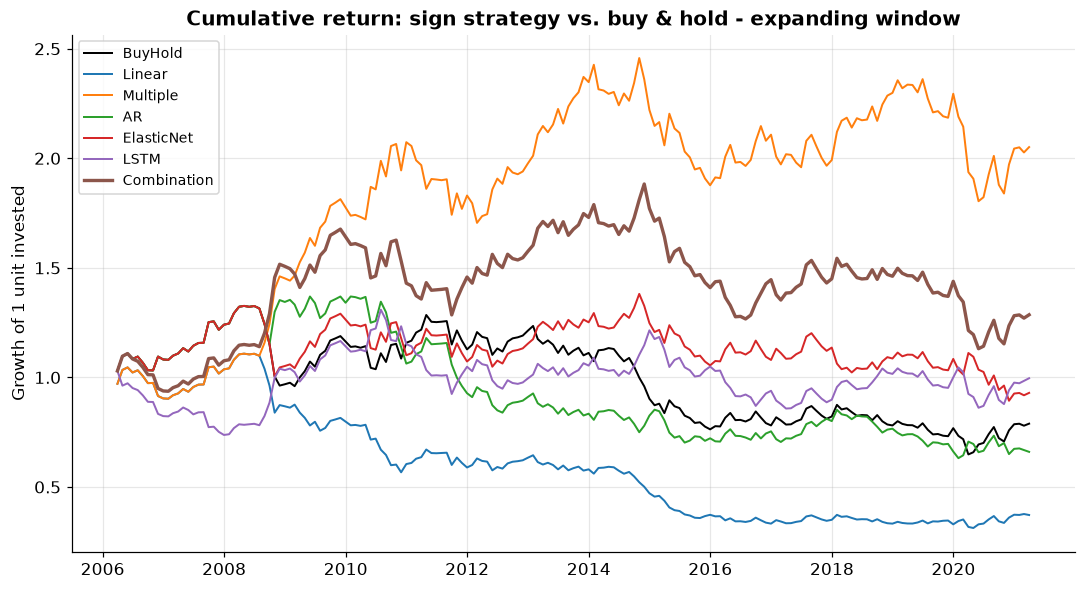

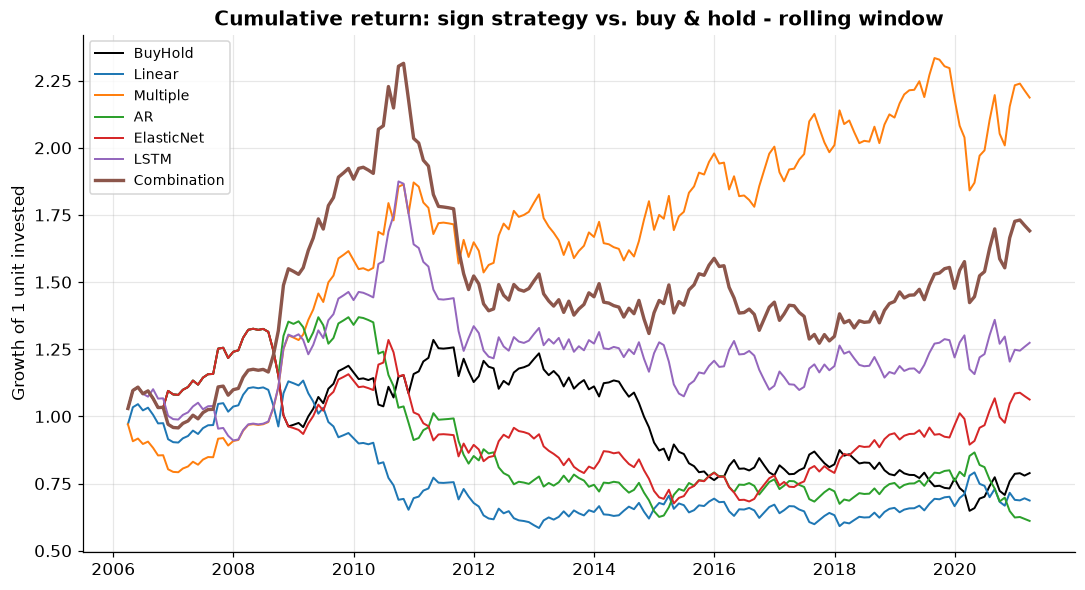

,expanding,expanding.1,expanding.2,rolling,rolling.1,rolling.2
NaN,total_return,sharpe,hit_rate,total_return,sharpe,hit_rate
Multiple,1.0509450491261196,0.45942525208578205,0.5414364640883977,1.1867389219374127,0.49601114812782804,0.569060773480663
Combination,0.2856921585939378,0.19842998384285482,0.5193370165745856,0.6906736426566737,0.35091645133920957,0.5580110497237569
LSTM,-0.003903001644831927,0.05746969368025884,0.5027624309392266,0.2738233184033221,0.19341817645466622,0.5303867403314917
ElasticNet,-0.07070126774183916,0.019720400709161753,0.5248618784530387,0.06266732108099093,0.09380324927072553,0.5193370165745856
BuyHold,-0.21118305679212346,-0.07071422328368208,NaN,-0.21118305679212346,-0.07071422328368208,NaN
AR,-0.3399548839019577,-0.1697444879937458,0.5027624309392266,-0.3892213373615595,-0.2124876336820163,0.5138121546961326
Linear,-0.6281398995294323,-0.48996154382607243,0.49171270718232046,-0.31333210731678873,-0.14778523412655903,0.5027624309392266


In [10]:
from src import trading
trading.run()
show("06_cumulative_returns_expanding.png", "06_cumulative_returns_rolling.png")
show_csv("06_strategy_compare.csv", index_col=0).round(3)

## Conclusion

The term-structure factors carry a **weak but economically meaningful directional
signal** for the krone. They do not beat a random walk on pure forecast accuracy
(in line with the literature), but a directional strategy on the multiple
regression — especially with a rolling window — still beat buy & hold clearly.
Results are reported deliberately without overstatement.